In [216]:
import sys
from pathlib import Path

sys.path.append(
    str(Path.cwd().parent)
)



In [218]:
import pandas as pd 
import numpy as np

from trueskill_opt import run_trueskill

In [219]:
df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\ufc_new_rolling.csv')

cutoff_date = pd.Timestamp("2026-04-01")
df['date'] = pd.to_datetime(df['date'])
df = df[df["date"] <= cutoff_date]
df = df[df['winner'] != 2]

C:\Users\jcmar\AppData\Local\Temp\ipykernel_71604\866142464.py:1: DtypeWarning: Columns (86,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\features_test_files\ufc_new_rolling.csv')


In [220]:
ratings_history, particle_filters = run_trueskill(df, inflate=True, particle_filter=True)

In [221]:
from sklearn.metrics import accuracy_score, log_loss

accuracy = accuracy_score(
    ratings_history["y_true"],
    ratings_history["p_red"] >= 0.5
)

loss = log_loss(
    ratings_history["y_true"],
    ratings_history["p_red"]
)

print("Accuracy:", accuracy)
print("Log loss:", loss)

Accuracy: 0.5938826466916355
Log loss: 0.6673748277183563


In [225]:
red_ratings = ratings_history[[
    "date", "fighter_red", "red_mu", "red_sigma"
]].rename(columns={
    "fighter_red": "fighter",
    "red_mu": "mu",
    "red_sigma": "sigma"
})
         
blue_ratings = ratings_history[[
    "date", "fighter_blue", "blue_mu", "blue_sigma"
]].rename(columns={
    "fighter_blue": "fighter",
    "blue_mu": "mu",
    "blue_sigma": "sigma"
})

all_ratings = pd.concat([red_ratings, blue_ratings], ignore_index=True)

top_peak_by_fighter = (
    all_ratings
    .sort_values("mu", ascending=False)
    .drop_duplicates("fighter")
    .head(25)
)

top_peak_by_fighter

,date,fighter,mu,sigma
7357,2024-11-16,Jon Jones,55.477001,6.141183
6229,2022-08-20,Kamaru Usman,53.565141,4.210620
15885,2025-11-15,Islam Makhachev,52.890701,4.185395
14444,2023-02-11,Alexander Volkanovski,52.587693,4.446185
1887,2013-07-06,Anderson Silva,52.159666,4.459097
5305,2020-10-24,Khabib Nurmagomedov,51.242738,4.999576
7738,2025-08-16,Dricus Du Plessis,51.106053,4.548723
3016,2015-12-12,Chris Weidman,50.871354,4.743430
4761,2019-08-17,Daniel Cormier,50.803882,4.396465
6328,2022-11-12,Israel Adesanya,50.517695,4.051121


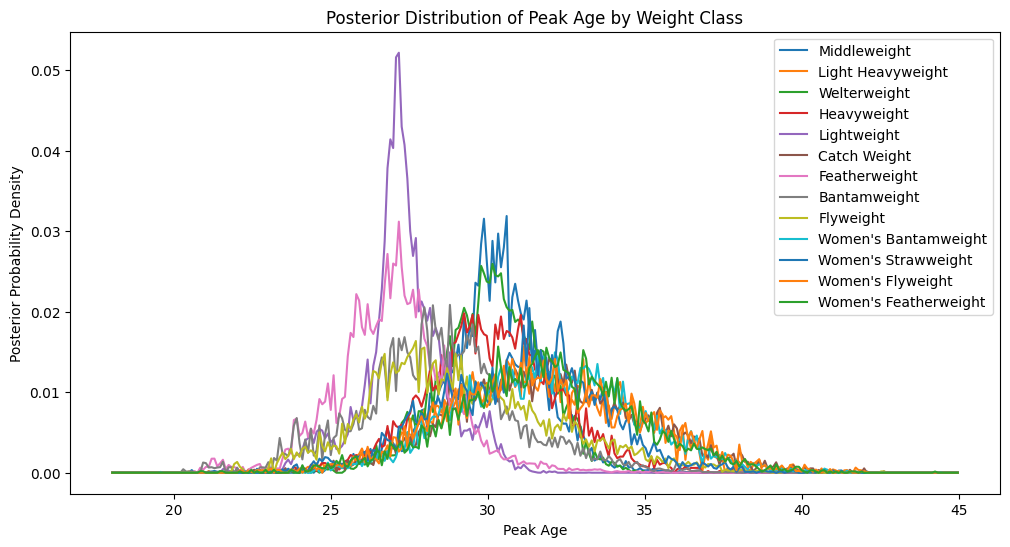

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for wc, pf in particle_filters.items():

    particles = pf["particles"]
    weights = pf["weights"]

    peak_age_particles = particles["peak_age"].values

    age_grid = np.linspace(18, 45, 300)

    hist, bins = np.histogram(
        peak_age_particles,
        bins=age_grid,
        weights=weights,
        density=True
    )
    hist = hist / hist.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    plt.plot(
        bin_centers,
        hist,
        label=wc
    )

plt.xlabel("Peak Age")
plt.ylabel("Posterior Probability Density")
plt.title("Posterior Distribution of Peak Age by Weight Class")

plt.legend()

plt.show()

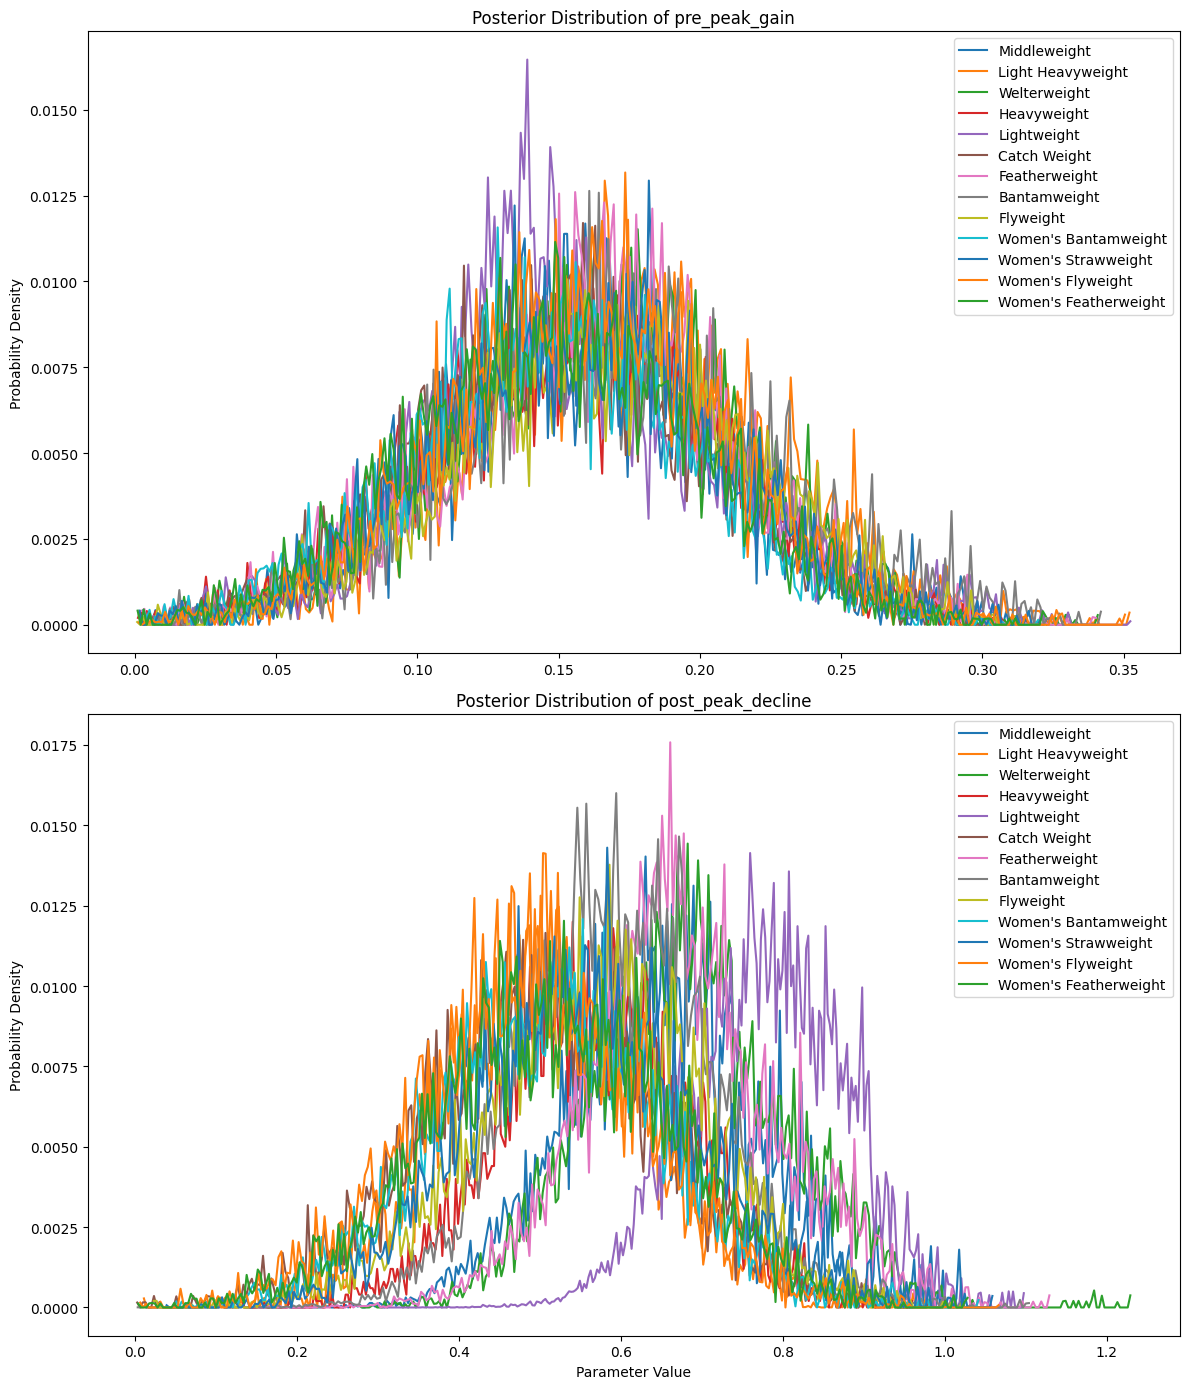

In [224]:

params_to_plot = [
    "pre_peak_gain",
    "post_peak_decline"
]

fig, axes = plt.subplots(
    nrows=len(params_to_plot),
    figsize=(12, 14)
)

for ax, param in zip(axes, params_to_plot):

    for wc, pf in particle_filters.items():

        particles = pf["particles"]
        weights = pf["weights"]

        values = particles[param].values

        x_grid = np.linspace(
            values.min(),
            values.max(),
            300
        )

        hist, bins = np.histogram(
            values,
            bins=x_grid,
            weights=weights,
            density=False
        )

        hist = hist / hist.sum()

        bin_centers = 0.5 * (bins[:-1] + bins[1:])

        ax.plot(
            bin_centers,
            hist,
            label=wc
        )

    ax.set_title(f"Posterior Distribution of {param}")
    ax.set_ylabel("Probability Density")
    ax.legend()

axes[-1].set_xlabel("Parameter Value")

plt.tight_layout()
plt.show()